In [8]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "kwill580"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
    print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
        print(f"📥 Cloning repo from {repo_url}...")
        os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")
# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()
if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #

#today_dir = "Assignments/HW4"
#os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

✅ Already inside repo folder: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/kwill580/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design


# STAT 7220 - Homework 4
## Mixed Effects Experiments
## Dr. Austin Brown
## Due Date: April 24, 2026

## Instructions:

The International Paralympic Committee is evaluating two new carbon-fiber blade designs: Model A (Aerostep) and Model B (Bionic-Flex). The goal is to determine if either new design yields meaningfully different 100-meter sprint times among T64 sprinters. Note, a T64 sprinter is an athlete with an absence of one leg below the knee.

Because sprint performance is highly dependent on an individual athlete’s biomechanics, muscle composition, and training level, the research team has recruited 5 professional T64 sprinters to participate in a study. Each athlete will perform three timed trials with both of the blade types in a randomized order. In this experiment, we want to control for the variability of individual athletes, but we are most interested in comparing the mean differences between the two blade designs. The results of this experiment are contained in the `Paralympic_Blade_Experiment.xlsx` file. With these data, I want you to:

1.  Briefly describe the objective of the experiment.

2.  Specify the outcome variable and how it is measured.
*
3.  Specify the independent variables, including which is fixed and which is random. What lurking variables may be present?

4.  Explain the difference between a random effect and a fixed effect. Why should we account for random effects in our designs?

5.  State the sets of null and alternative hypotheses for this experiment.

6.  Perform appropriate exploratory analysis, including data visualizations. Do the results of these analyses support the null or alternative hypotheses more strongly?

  Athlete_ID   Blade_Type  Trial  Sprint_Time
0  Athlete_1     Aerostep      1        11.63
1  Athlete_1     Aerostep      2        11.57
2  Athlete_1     Aerostep      3        11.39
3  Athlete_1  Bionic-Flex      1        11.74
4  Athlete_1  Bionic-Flex      2        11.68
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Athlete_ID   30 non-null     object 
 1   Blade_Type   30 non-null     object 
 2   Trial        30 non-null     int64  
 3   Sprint_Time  30 non-null     float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.1+ KB
None
  Athlete_ID   Blade_Type       mean       std
0  Athlete_1     Aerostep  11.530000  0.124900
1  Athlete_1  Bionic-Flex  11.703333  0.032146
2  Athlete_2     Aerostep  10.960000  0.034641
3  Athlete_2  Bionic-Flex  11.133333  0.051316
4  Athlete_3     Aerostep  11.273333  0.032146
5  Athlete_3  Bionic-

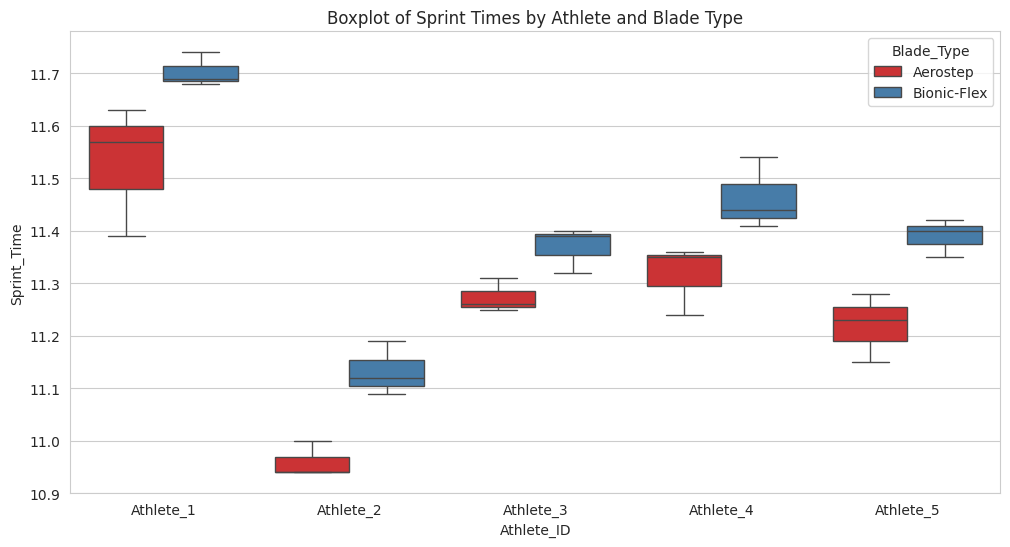

In [3]:
## Import Libraries ##
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.formula.api import mixedlm
from scipy import stats
from scipy.stats import chi2
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns

## Import Data ##

blade = pd.read_excel("/content/STAT-7220-Applied-Experimental-Design/Assignments/HW4/STAT Paralympic_Blade_Experiment.xlsx")

## Evaluate Data Integrity ##

print(blade.head())
print(blade.info())

## Run Exploratory Data Analysis ##

## Calculate Means and SDs by Athlete and Blade ##

blade_stats = blade.groupby(['Athlete_ID', 'Blade_Type'])['Sprint_Time'].agg(['mean', 'std']).reset_index()
print(blade_stats)

## Visualize Data using Boxplots ##

sns.set_style("whitegrid") # Use a clean background
plt.figure(figsize=(12, 6))
sns.boxplot(x='Athlete_ID', y='Sprint_Time', hue='Blade_Type', data=blade, palette='Set1')
plt.title('Boxplot of Sprint Times by Athlete and Blade Type')
plt.xlabel('Athlete_ID')
plt.ylabel('Sprint_Time')
plt.legend(title='Blade_Type')
plt.show()

* The summary statistics support the null hypothesis. The boxplot shows a gap between the sprint time of athlete 1 and athlete 2, which suggest there is a  difference in group means.
7. Fit the mixed effects model. Using the model residuals, check the assumption of normality using both a testing method and a visual method. Do we have support for the assumption of normality from the data? Why or why not?

In [4]:
## Question 7 Code ##
## Fit the Full Mixed Effects Model ##

blade_mod = mixedlm("Sprint_Time~Athlete_ID",data=blade, groups=blade["Athlete_ID"])
mixed_result = blade_mod.fit(reml=False,method='nm') # Fit using ML for comparison

## Fit the Reduced Model (Note this is keeping the fixed effect) ##

blade_reduced_mod = ols('Sprint_Time ~ Athlete_ID', data=blade).fit()

## Parse out model residuals ##

residuals = mixed_result.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")


Likelihood Ratio Test Statistic: -1.1444090546319785e-06, p-value: 0.5
               Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    Sprint_Time
No. Observations:     30         Method:                ML         
No. Groups:           5          Scale:                 0.0085     
Min. group size:      6          Log-Likelihood:        28.8943    
Max. group size:      6          Converged:             Yes        
Mean group size:      6.0                                          
-------------------------------------------------------------------
                        Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept               11.617    0.038 308.094 0.000 11.543 11.691
Athlete_ID[T.Athlete_2] -0.570    0.053 -10.690 0.000 -0.675 -0.465
Athlete_ID[T.Athlete_3] -0.295    0.053  -5.532 0.000 -0.400 -0.190
Athlete_ID[T.Athlete_4] -0.227    0.053  -4.251 0.000 -0.331

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


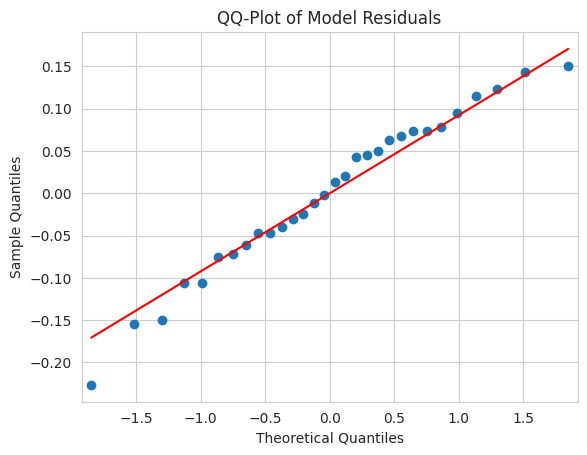

Shapiro-Wilk Test Results:
Statistic: 0.9730983930248372
p-value: 0.626940078261963
Fail to reject the null hypothesis - Residuals are normally distributed.


In [11]:
## Parse out model residuals ##

residuals = mixed_result.resid

## Test of Normality ##

## QQ-Plot ##

sm.qqplot(residuals, line='s')
plt.title("QQ-Plot of Model Residuals")
plt.show()

## Shapiro-Wilk Test ##

shapiro_test = stats.shapiro(residuals)

print("Shapiro-Wilk Test Results:")
print(f"Statistic: {shapiro_test.statistic}")
print(f"p-value: {shapiro_test.pvalue}")
if shapiro_test.pvalue < 0.05:
    print("Reject the null hypothesis - Residuals are not normally distributed.")
else:
    print("Fail to reject the null hypothesis - Residuals are normally distributed.")

8. **Using the visual method described in the lecture notes**, check the assumption of constant variance. Do we have support for the assumption of constant variance? Why or why not?

Variance Components:
              Group
Group  3.253937e-10
Residual Variance: 0.008529999999999979


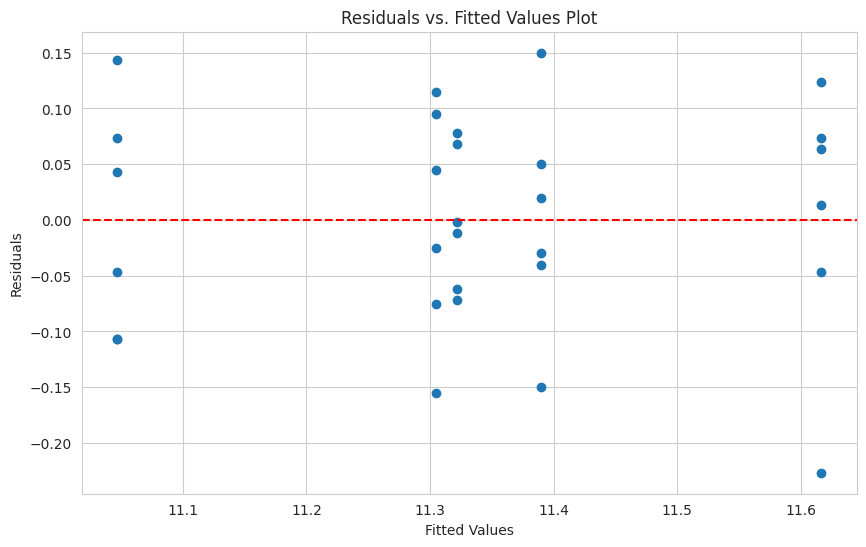

In [14]:
## Visual Check for Constant Variance (Homoscedasticity) ##

plt.figure(figsize=(10, 6))
plt.scatter(mixed_result.fittedvalues, mixed_result.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values Plot')
plt.show()

# Interpretation for constant variance
# If the points are randomly scattered around the horizontal line at 0 with no discernible pattern,
# it suggests that the assumption of constant variance holds. If there's a pattern (e.g., a fanning out or fanning in),
# then the assumption may be violated.

9. Report and interpret the result of the random effect. Which of the two hypotheses for the random effect are more strongly supported by the data?

In [6]:
## Question 9 Code ##

10. Report and interpret the result of the fixed effect. Which of the two hypotheses for the fixed effect are more strongly supported by the data?

In [7]:
## Question 10 Code ##

11. Finally, provide a brief contextual conclusion for this experiment. Discuss experiment limitations and future directions.

In [ ]:
## Perform Likelihood Ratio Test ##

ll_full = mixed_result.llf
ll_reduced = blade_reduced_mod.llf

LR_stat = 2 * (ll_full - ll_reduced)
p_value = 0.5 * (1 - chi2.cdf(LR_stat, df=1))
print(f"Likelihood Ratio Test Statistic: {LR_stat}, p-value: {p_value}")

## Perform test for fixed effect ##

print(mixed_result.summary())
